- Train: 70%
- Validation: 10%
- Test: 20% 



In [5]:
from pathlib import Path
import pandas as pd

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "preprocess").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "preprocess").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

SPLIT_DIR = PROJECT_ROOT / "data" / "processed" / "split_images"

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("Split folder exists:", SPLIT_DIR.exists())
print("Split folder:", SPLIT_DIR)


Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
Split folder exists: True
Split folder: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\data\processed\split_images


In [6]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

records = []

for split_name in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split_name

    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            image_files = [
                p for p in class_dir.rglob("*")
                if p.suffix.lower() in IMAGE_EXTENSIONS
            ]

            records.append({
                "split": split_name,
                "class_name": class_dir.name,
                "count": len(image_files)
            })

folder_summary = pd.DataFrame(records)
folder_summary


,split,class_name,count
0,train,0Normal,316
1,train,1Doubtful,308
2,train,2Mild,134
3,train,3Moderate,122
4,train,4Severe,144
5,val,0Normal,45
6,val,1Doubtful,44
7,val,2Mild,19
8,val,3Moderate,18
9,val,4Severe,20


In [7]:
pivot_summary = folder_summary.pivot_table(
    index="class_name",
    columns="split",
    values="count",
    fill_value=0
)

pivot_summary = pivot_summary[[col for col in ["train", "val", "test"] if col in pivot_summary.columns]]

pivot_summary


split,train,val,test
class_name,,,
0Normal,316.0,45.0,91.0
1Doubtful,308.0,44.0,88.0
2Mild,134.0,19.0,38.0
3Moderate,122.0,18.0,35.0
4Severe,144.0,20.0,42.0


In [8]:
split_totals = folder_summary.groupby("split")["count"].sum().reset_index()
split_totals
total_images = split_totals["count"].sum()

split_totals["ratio"] = split_totals["count"] / total_images * 100

split_totals

,split,count,ratio
0,test,294,20.081967
1,train,1024,69.945355
2,val,146,9.972678


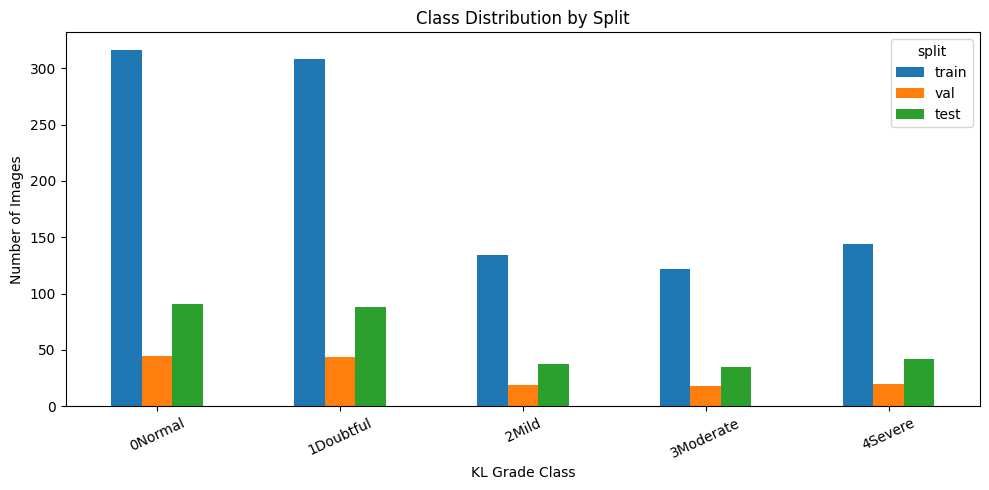

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\split_folder_distribution.png


In [9]:
import matplotlib.pyplot as plt

ax = pivot_summary.plot(kind="bar", figsize=(10, 5))

ax.set_title("Class Distribution by Split")
ax.set_xlabel("KL Grade Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=25)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "split_folder_distribution.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

